In [8]:
import os
import glob
import random
import logging
from typing import List, Tuple, Optional
import numpy as np
import mne
import matplotlib.pyplot as plt
from collections import Counter, defaultdict
import pandas as pd

In [9]:
"""
Scan CHB-MIT EDF files, collect channel statistics, and plot distributions.

- Global frequency: how many EDF files each channel appears in
- Patient coverage: for each channel, how many patients have that channel

Use this to decide which common channels to pick for CHANNELS.
"""

# -------------------------------------------------------------------
# CONFIG
# -------------------------------------------------------------------

DATA_ROOT = "/kaggle/input/seizure-epilepcy-chb-mit-eeg-dataset-pediatric/chb-mit-scalp-eeg-database-1.0.0"

# set to True if you want less MNE console output
MNE_VERBOSE = "ERROR"   # or "WARNING" / "INFO"

# -------------------------------------------------------------------
# SCANNING FUNCTIONS
# -------------------------------------------------------------------

def list_patient_dirs(root):
    """Return sorted list of patient directory names ('chb01', 'chb02', ...)."""
    return sorted(
        d for d in os.listdir(root)
        if os.path.isdir(os.path.join(root, d)) and d.lower().startswith("chb")
    )

def scan_all_channels(data_root):
    """
    Scan all EDF files and collect:
      - global_channel_counter: channel -> #edf files containing it
      - patient_channel_counter: patient_id -> Counter(channel -> #edf files)
      - channel_patients: channel -> set(patient_ids)
    """
    patients = list_patient_dirs(data_root)
    print("Found patients:", patients)

    global_channel_counter = Counter()
    patient_channel_counter = defaultdict(Counter)
    channel_patients = defaultdict(set)

    total_files = 0

    for pid in patients:
        patient_dir = os.path.join(data_root, pid)
        edf_files = sorted(glob.glob(os.path.join(patient_dir, "*.edf")))
        print(f"{pid}: {len(edf_files)} EDF files")

        for f in edf_files:
            total_files += 1
            try:
                raw = mne.io.read_raw_edf(f, preload=False, verbose=MNE_VERBOSE)
            except Exception as e:
                print(f"  !! Failed to read {f}: {e}")
                continue

            chs = list(raw.ch_names)

            # Update global counts
            # We count each channel at most once per EDF file
            uniq_chs = set(chs)
            global_channel_counter.update(uniq_chs)

            # Per-patient counts
            patient_channel_counter[pid].update(uniq_chs)

            # Channel -> patients mapping
            for ch in uniq_chs:
                channel_patients[ch].add(pid)

    print(f"\nScanned {total_files} EDF files in total.")
    return global_channel_counter, patient_channel_counter, channel_patients, total_files

# -------------------------------------------------------------------
# PLOTTING / SUMMARY
# -------------------------------------------------------------------

def plot_global_channel_frequency(global_counter, total_files, top_n=None):
    """
    Plot global frequency of each channel (how many EDF files contain it).
    If top_n is not None, show only the top N channels.
    """
    # Sort channels by count descending
    items = sorted(global_counter.items(), key=lambda x: x[1], reverse=True)
    if top_n is not None:
        items = items[:top_n]

    ch_names = [k for k, _ in items]
    counts = np.array([v for _, v in items])
    percents = counts / total_files * 100.0

    df = pd.DataFrame(
        {"channel": ch_names, "n_files": counts, "percent_files": percents}
    )
    print("\nGlobal channel frequency (top rows):")
    print(df.head(20))

    plt.figure(figsize=(max(10, 0.4 * len(ch_names)), 5))
    plt.bar(ch_names, counts)
    plt.xticks(rotation=90)
    plt.ylabel("Number of EDF files")
    plt.title("Global channel frequency (files containing each channel)")
    plt.tight_layout()
    plt.show()

    return df


def plot_channel_patient_coverage(channel_patients):
    """
    Plot how many patients have each channel at least once.
    """
    channels = sorted(channel_patients.keys())
    n_patients = np.array([len(channel_patients[ch]) for ch in channels])

    df = pd.DataFrame(
        {"channel": channels, "n_patients": n_patients}
    ).sort_values("n_patients", ascending=False)

    print("\nChannel coverage by patients (top rows):")
    print(df.head(40))

    plt.figure(figsize=(max(10, 0.4 * len(channels)), 5))
    plt.bar(df["channel"], df["n_patients"])
    plt.xticks(rotation=90)
    plt.ylabel("Number of patients")
    plt.title("Channel coverage across patients")
    plt.tight_layout()
    plt.show()

    return df


def plot_patient_channel_heatmap(patient_channel_counter, min_files_per_channel=1):
    """
    Optional: heatmap of (patients x channels) = number of EDF files
    where that channel appears. Useful to see patient-specific layouts.

    min_files_per_channel: only keep channels that appear in at least this many files overall.
    """
    # Build DataFrame
    all_channels = set()
    for c in patient_channel_counter.values():
        all_channels.update(c.keys())
    all_channels = sorted(all_channels)

    patients = sorted(patient_channel_counter.keys())

    data = []
    for pid in patients:
        counts = patient_channel_counter[pid]
        row = [counts.get(ch, 0) for ch in all_channels]
        data.append(row)

    df = pd.DataFrame(data, index=patients, columns=all_channels)

    # Filter out very rare channels if desired
    if min_files_per_channel > 1:
        keep_cols = (df.sum(axis=0) >= min_files_per_channel)
        df = df.loc[:, keep_cols]

    if df.empty:
        print("Heatmap skipped: no channels left after filtering.")
        return df

    plt.figure(figsize=(0.4 * df.shape[1] + 4, 0.3 * df.shape[0] + 3))
    plt.imshow(df.values, aspect="auto", interpolation="nearest")
    plt.colorbar(label="#EDF files with channel")
    plt.xticks(range(df.shape[1]), df.columns, rotation=90)
    plt.yticks(range(df.shape[0]), df.index)
    plt.title("Patient–channel EDF count heatmap")
    plt.tight_layout()
    plt.show()

    return df

Found patients: ['chb01', 'chb02', 'chb03', 'chb04', 'chb05', 'chb06', 'chb07', 'chb08', 'chb09', 'chb10', 'chb11', 'chb12', 'chb13', 'chb14', 'chb15', 'chb16', 'chb17', 'chb18', 'chb19', 'chb20', 'chb21', 'chb22', 'chb23', 'chb24']
chb01: 42 EDF files
chb02: 36 EDF files
chb03: 38 EDF files
chb04: 42 EDF files
chb05: 39 EDF files
chb06: 18 EDF files
chb07: 19 EDF files
chb08: 20 EDF files
chb09: 19 EDF files
chb10: 25 EDF files
chb11: 35 EDF files
chb12: 24 EDF files
chb13: 33 EDF files
chb14: 26 EDF files
chb15: 40 EDF files
chb16: 19 EDF files
chb17: 21 EDF files
chb18: 36 EDF files
chb19: 30 EDF files
chb20: 29 EDF files
chb21: 33 EDF files
chb22: 31 EDF files
chb23: 9 EDF files
chb24: 22 EDF files

Scanned 686 EDF files in total.

Global channel frequency (top rows):
    channel  n_files  percent_files
0    FP1-F3      683      99.562682
1    FP2-F8      683      99.562682
2     P8-O2      683      99.562682
3    FP2-F4      683      99.562682
4     CZ-PZ      683      99.562682
5

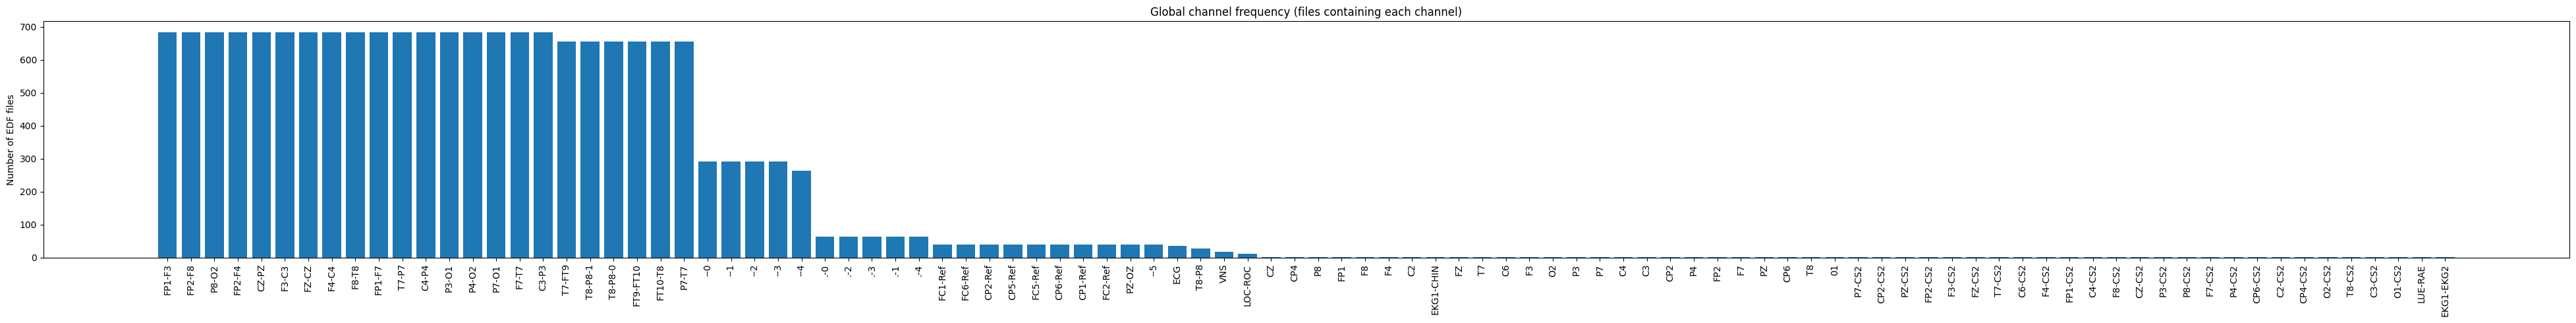


Channel coverage by patients (top rows):
     channel  n_patients
49     F8-T8          24
34     CZ-PZ          24
42     F4-C4          24
46     F7-T7          24
19     C4-P4          24
56    FP1-F3          24
57    FP1-F7          24
16     C3-P3          24
60    FP2-F4          24
61    FP2-F8          24
62   FT10-T8          24
63  FT9-FT10          24
66     FZ-CZ          24
74     P3-O1          24
77     P4-O2          24
80     P7-O1          24
81     P7-T7          24
84     P8-O2          24
90    T7-FT9          24
91     T7-P7          24
95   T8-P8-0          24
96   T8-P8-1          24
39     F3-C3          24
1        --1          11
0        --0          11
2        --2          11
3        --3          11
4        --4          10
94     T8-P8           6
8        .-2           2
10       .-4           2
7        .-1           2
9        .-3           2
6        .-0           2
71    O2-CS2           1
75        P4           1
73    P3-CS2           1
72      

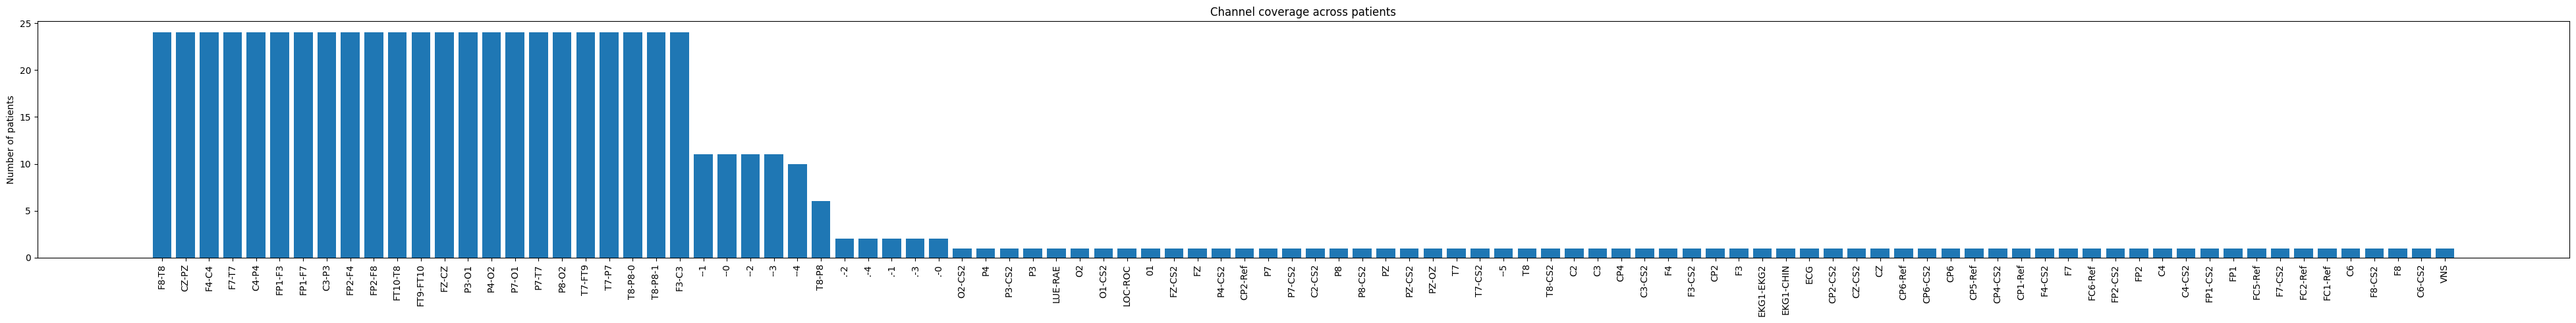

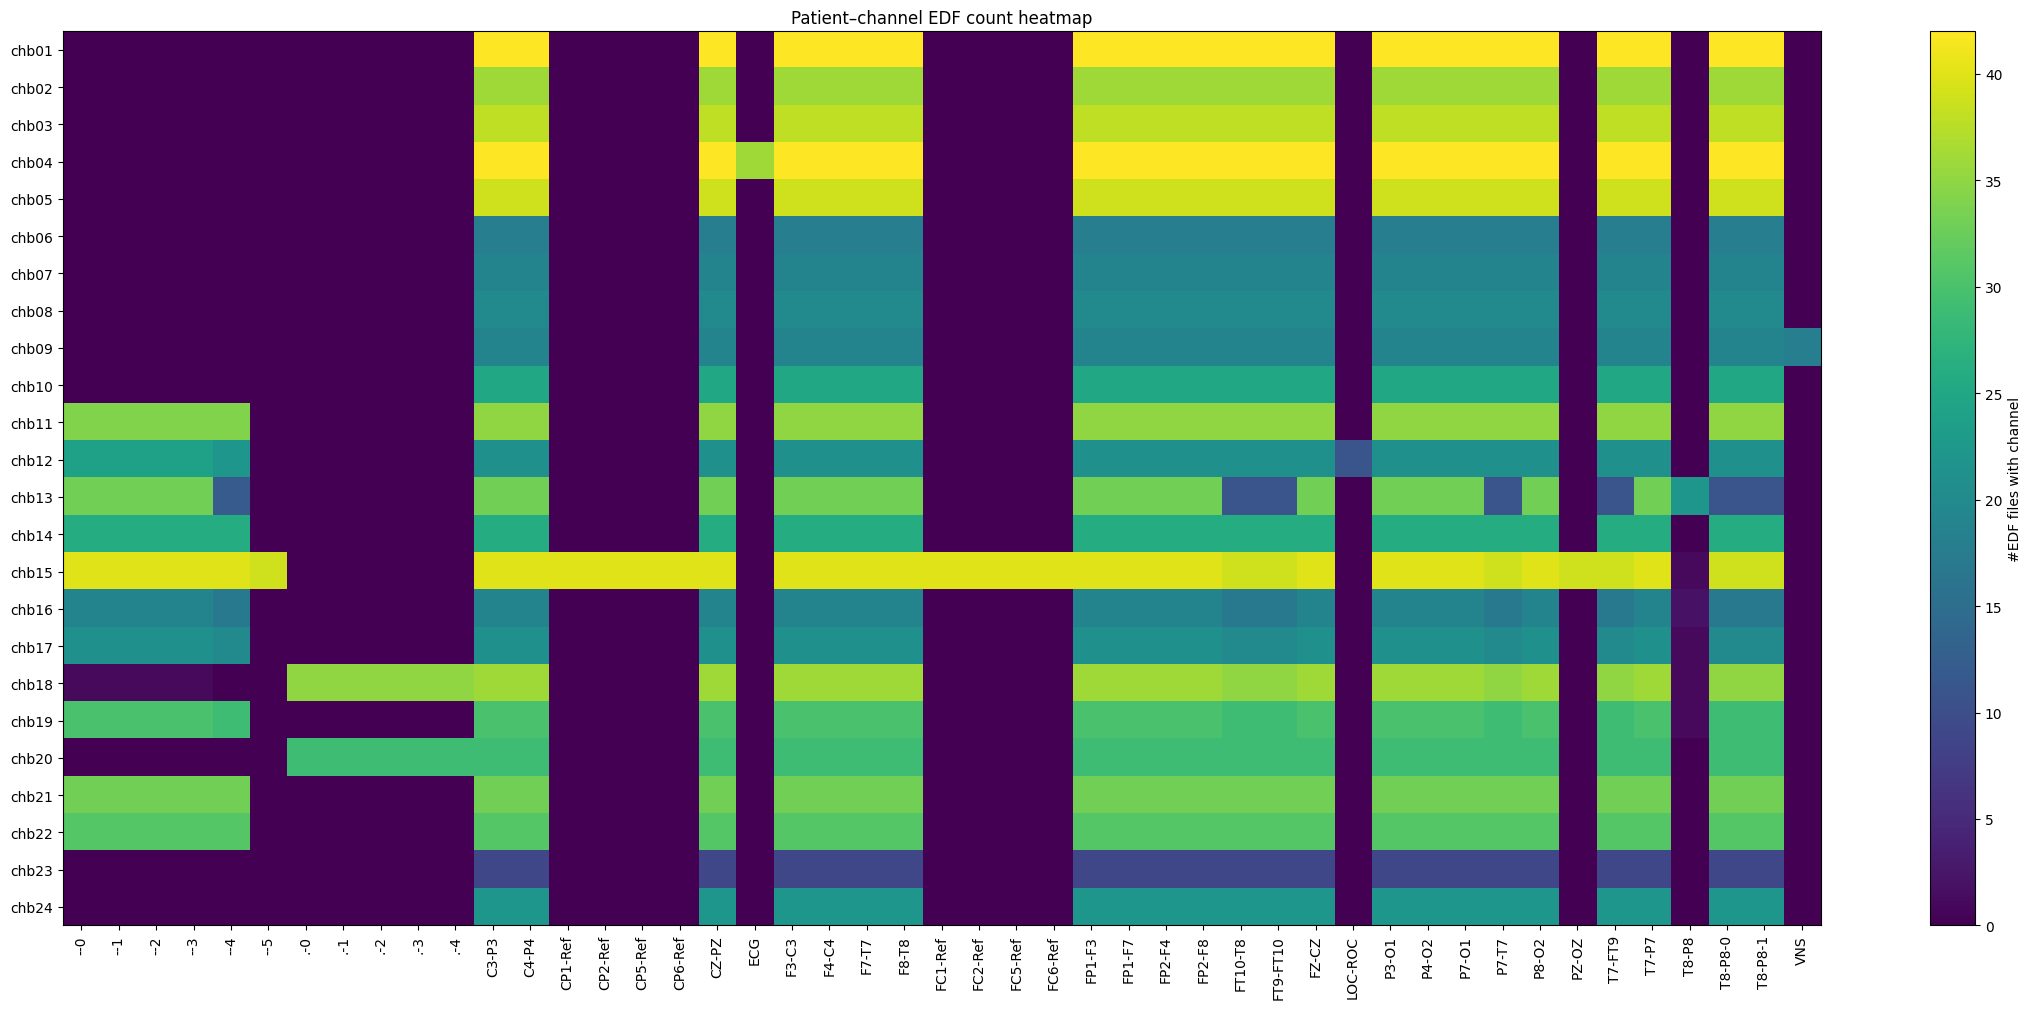


Channels present in ≥90% of patients:
['F8-T8', 'CZ-PZ', 'F4-C4', 'F7-T7', 'C4-P4', 'FP1-F3', 'FP1-F7', 'C3-P3', 'FP2-F4', 'FP2-F8', 'FT10-T8', 'FT9-FT10', 'FZ-CZ', 'P3-O1', 'P4-O2', 'P7-O1', 'P7-T7', 'P8-O2', 'T7-FT9', 'T7-P7', 'T8-P8-0', 'T8-P8-1', 'F3-C3']


In [10]:
global_counter, patient_counter, channel_patients, total_files = scan_all_channels(DATA_ROOT)

# 1) Global frequency distribution
df_global = plot_global_channel_frequency(global_counter, total_files)

# 2) Channel coverage across patients
df_cov = plot_channel_patient_coverage(channel_patients)

# 3) Optional: patient-channel heatmap (comment out if too heavy)
_ = plot_patient_channel_heatmap(patient_counter, min_files_per_channel=5)

# Example: list channels that appear in at least 90% of patients
n_pat = len(channel_patients[next(iter(channel_patients))] | set())  # crude
# better: count from union of all patient sets
all_patients_set = set()
for s in channel_patients.values():
    all_patients_set |= s
n_pat = len(all_patients_set)

df_cov["patient_coverage_frac"] = df_cov["n_patients"] / n_pat
common_channels = df_cov[df_cov["patient_coverage_frac"] >= 0.9]["channel"].tolist()
print("\nChannels present in ≥90% of patients:")
print(common_channels)